In [1]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.optim import AdamW
from torch.nn.functional import softmax
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, precision_recall_curve, auc, roc_curve
import random
import matplotlib.pyplot as plt

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

set_seed(42)

In [2]:
MODEL = "NaturalAntibody/nanoBERT"
train_csv = "data/CD-HIT/90/EGFR/train_data.csv"
val_csv = "data/CD-HIT/90/EGFR/val_data.csv"
seq_col = "Sequence"
label_col = "Label"
cluster_col = "Cluster_name"
max_len = 160
num_labels = 2
epochs = 10
learning_rate = 2e-5
batch_size = 32
space_separated = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tok = AutoTokenizer.from_pretrained(MODEL, use_fast=True)
model = AutoModelForSequenceClassification.from_pretrained(MODEL, num_labels=num_labels).to(device)


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at NaturalAntibody/nanoBERT and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [3]:
for param in model.base_model.parameters():
    param.requires_grad = False

opt = AdamW((param for param in model.parameters() if param.requires_grad), lr=learning_rate)

In [4]:
train_df = pd.read_csv(train_csv)
val_df = pd.read_csv(val_csv)

train_seqs = train_df[seq_col].astype(str).tolist()
train_labels = train_df[label_col].astype(int).tolist()
val_seqs = val_df[seq_col].astype(str).tolist()
val_labels = val_df[label_col].astype(int).tolist()

In [5]:
class DS(Dataset):
    def __init__(self, seqs, labels, clusters = None, cluster_key ="Cluster_name"):
        self.seqs = seqs
        self.labels = labels
        self.clusters = clusters
        self.cluster_key = cluster_key

        if self.clusters is not None:
            assert len(self.seqs) == len(self.clusters), "The number of sequences and clusters must be the same."

    def __len__(self):
        return len(self.seqs)

    def __getitem__(self, idx):
        s = self.seqs[idx]
        if space_separated:
            s = " ".join(list(s))
            
        x = tok(
            s,
            truncation=True,
            max_length=max_len,
            padding="max_length",
            return_tensors="pt",
        )
        x = {k: v.squeeze(0) for k, v in x.items()}
        x["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        if self.clusters is not None:
            x[self.cluster_key] = torch.tensor(self.clusters[idx], dtype=torch.long)
        return x

In [6]:
def eval_metrics(model, dl):
    model.eval()
    all_scores = []
    all_labels = []
    with torch.no_grad():
        for b in dl:
            b = {k: v.to(device) for k, v in b.items()}
            outputs = model(input_ids=b["input_ids"], attention_mask=b["attention_mask"])
            logits = outputs.logits
            scores = torch.softmax(logits, dim=-1)[:, 1]
            all_scores.append(scores.cpu())
            all_labels.append(b["labels"].cpu())
    all_scores = torch.cat(all_scores).numpy()
    all_labels = torch.cat(all_labels).numpy()

    all_preds = (all_scores > 0.5).astype(int)

    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds)

    return accuracy, precision, recall, f1


In [7]:
train_dl = DataLoader(DS(train_seqs, train_labels), batch_size=batch_size, shuffle=True)
val_dl = DataLoader(DS(val_seqs, val_labels), batch_size=batch_size, shuffle=False)

In [8]:
for epoch in range(epochs):
    model.train()
    total_loss = 0.0
    for b in train_dl:
        b = {k: v.to(device) for k, v in b.items()}
        opt.zero_grad()
        outputs = model(**b)
        loss = outputs.loss
        loss.backward()
        opt.step()
        total_loss += loss.item()
    train_loss = total_loss / max(1, len(train_dl))
    val_acc, val_prec, val_rec, val_f1 = eval_metrics(model, val_dl)
    print(f"Epoch {epoch+1}: train loss {train_loss:.4f}, val acc {val_acc:.4f}, val f1 {val_f1:.4f}")

Epoch 1: train loss 0.6862, val acc 0.5820, val f1 0.6267


Epoch 2: train loss 0.6821, val acc 0.5846, val f1 0.6020


Epoch 3: train loss 0.6816, val acc 0.5874, val f1 0.6121


Epoch 4: train loss 0.6811, val acc 0.5888, val f1 0.6259


Epoch 5: train loss 0.6811, val acc 0.5904, val f1 0.6161


Epoch 6: train loss 0.6813, val acc 0.5867, val f1 0.5311


Epoch 7: train loss 0.6804, val acc 0.5928, val f1 0.5700


Epoch 8: train loss 0.6809, val acc 0.5916, val f1 0.6075


Epoch 9: train loss 0.6802, val acc 0.5884, val f1 0.6061


Epoch 10: train loss 0.6806, val acc 0.5891, val f1 0.5685


In [9]:
test_csv = "data/CD-HIT/90/EGFR/test_combined_data.csv"
test_df = pd.read_csv(test_csv)
test_seqs = test_df[seq_col].astype(str).tolist()
test_labels = test_df[label_col].astype(int).tolist()
test_cluster_ids, _ = pd.factorize(test_df[cluster_col].astype(str))
test_cluster_ids = test_cluster_ids.tolist()
test_dl = DataLoader(DS(test_seqs, test_labels, clusters=test_cluster_ids, cluster_key="Cluster_name"), batch_size=batch_size, shuffle=False)

In [10]:
def diversity_at_k (cluster_ids, scores, k=100):
    cluster_ids = np.asarray(cluster_ids)   # <-- add this
    scores = np.asarray(scores) 
    k = min(k, len(scores))
    top_idx = np.argsort(scores)[::-1][:k]
    return len(np.unique(cluster_ids[top_idx]))
    

In [11]:
def metrics_at_k(all_labels, all_scores, k):
    all_labels = np.array(all_labels)
    all_scores = np.array(all_scores)

    sorted_indices = np.argsort(all_scores)[::-1]
    k_eff = min(k, len(all_labels))
    top_k_indices = sorted_indices[:k_eff]

    top_k_labels = all_labels[top_k_indices]
    
    num_pos_total = all_labels.sum()
    num_pos_top_k = top_k_labels.sum()

    precision_at_k = num_pos_top_k / max(1, k_eff)
    recall_at_k = num_pos_top_k / max(1, num_pos_total)

    prevalence = num_pos_total / len(all_labels)
    ef_at_k = precision_at_k / max(prevalence, 1e-12)

    return precision_at_k, recall_at_k, ef_at_k


In [12]:
def evaluate_test(model, test_dl, device, k=100, cluster_key=None):
    model.eval()

    all_labels = []
    all_preds = []
    all_scores = []
    all_clusters = [] if cluster_key is not None else None

    with torch.no_grad():
        for b in test_dl:

            if cluster_key is not None:
                if cluster_key not in b:
                    raise KeyError(f"Key {cluster_key} not found in the batch.")
                cluster = b[cluster_key]
                all_clusters.extend(cluster.cpu().numpy())

            labels = b["labels"].to(device)
            b = {kk: vv.to(device) for kk, vv in b.items() if kk !=cluster_key}

            outputs = model(**b)
            logits = outputs.logits
            probs = softmax(logits, dim=-1)
            preds = torch.argmax(probs, dim=-1)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_scores.extend(probs[:, 1].cpu().numpy())
    
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)
    roc_auc = roc_auc_score(all_labels, all_scores)
    precision_1, recall_1, _ = precision_recall_curve(all_labels, all_scores)
    pr_auc = auc(recall_1, precision_1)

    precision_at_k, recall_at_k, ef_at_k = metrics_at_k(all_labels, all_scores, k)
    precision_at_1000, _, _ = metrics_at_k(all_labels, all_scores, 1000)

    metrics = {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        f"precision@{k}": precision_at_k,
        f"recall@{k}": recall_at_k,
        f"ef@{k}": ef_at_k,
        "precision@1000": precision_at_1000
    }

    if cluster_key is not None:
        div_at_k = diversity_at_k(all_clusters, all_scores, k=k)
        metrics[f"diversity@{k}"] = div_at_k

    return metrics




In [13]:
metrics = evaluate_test(model, test_dl, device, k=100, cluster_key="Cluster_name")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")

accuracy: 0.5812
precision: 0.5899
recall: 0.5395
f1: 0.5636
roc_auc: 0.6133
pr_auc: 0.6019
precision@100: 0.7600
recall@100: 0.0054
ef@100: 1.5165
precision@1000: 0.7160
diversity@100: 92.0000


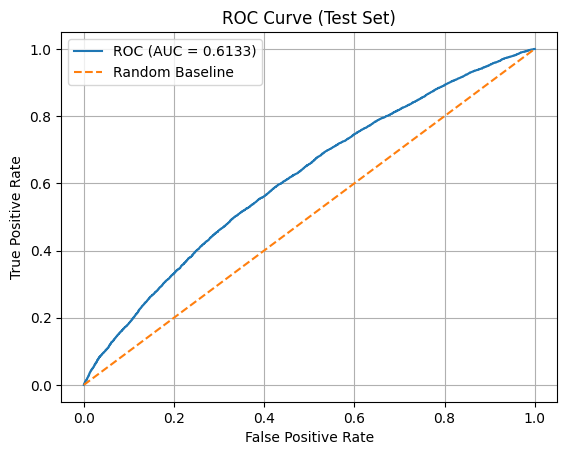

In [14]:
model.eval()
all_labels = []
all_scores = []

with torch.no_grad():
    for b in test_dl:
        labels = b["labels"].to(device)
        b = {kk: vv.to(device) for kk, vv in b.items() if kk != "Cluster_name"}  # keep this if Cluster_name exists

        outputs = model(**b)
        probs = torch.softmax(outputs.logits, dim=-1)

        all_labels.extend(labels.cpu().numpy())
        all_scores.extend(probs[:, 1].cpu().numpy())

# 2) ROC points + AUC
fpr, tpr, thresholds = roc_curve(all_labels, all_scores)
roc_auc = auc(fpr, tpr)

# 3) Plot
plt.figure()
plt.plot(fpr, tpr, label=f"ROC (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Baseline")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Test Set)")
plt.legend()
plt.grid(True)
plt.show()